In [1]:
%pip install opencv-python opencv-python-headless
%pip install opencv-contrib-python
%pip install numpy
%pip install matplotlib



Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 25.1.1
[notice] To update, run: C:\Users\aditi\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


     ---------------------------------------- 0.0/46.2 MB ? eta -:--:--
     ---------------------------------------- 0.1/46.2 MB 1.5 MB/s eta 0:00:31
     ---------------------------------------- 0.2/46.2 MB 2.8 MB/s eta 0:00:17
     ---------------------------------------- 0.3/46.2 MB 2.8 MB/s eta 0:00:17
      --------------------------------------- 0.6/46.2 MB 3.3 MB/s eta 0:00:14
      --------------------------------------- 0.8/46.2 MB 3.6 MB/s eta 0:00:13
      --------------------------------------- 1.0/46.2 MB 3.9 MB/s eta 0:00:12
     - -------------------------------------- 1.2/46.2 MB 3.9 MB/s eta 0:00:12
     - -------------------------------------- 1.4/46.2 MB 3.8 MB/s eta 0:00:12
     - -------------------------------------- 1.5/46.2 MB 3.7 MB/s eta 0:00:13
     - -------------------------------------- 1.6/46.2 MB 3.4 MB/s eta 0:00:14
     - -------------------------------------- 1.8/46.2 MB 3.6 MB/s eta 0:00:13
     - -------------------------------------- 1.8/46.2 MB 3


[notice] A new release of pip is available: 23.0.1 -> 25.1.1
[notice] To update, run: C:\Users\aditi\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 25.1.1
[notice] To update, run: C:\Users\aditi\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


     ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
     ---------------------------------------- 0.1/8.1 MB 2.6 MB/s eta 0:00:04
     - -------------------------------------- 0.2/8.1 MB 3.1 MB/s eta 0:00:03
     - -------------------------------------- 0.3/8.1 MB 2.5 MB/s eta 0:00:04
     -- ------------------------------------- 0.4/8.1 MB 2.6 MB/s eta 0:00:03
     -- ------------------------------------- 0.4/8.1 MB 2.6 MB/s eta 0:00:03
     -- ------------------------------------- 0.4/8.1 MB 2.6 MB/s eta 0:00:03
     -- ------------------------------------- 0.4/8.1 MB 2.6 MB/s eta 0:00:03
     -- ------------------------------------- 0.4/8.1 MB 2.6 MB/s eta 0:00:03
     -- ------------------------------------- 0.4/8.1 MB 2.6 MB/s eta 0:00:03
     -- ------------------------------------- 0.5/8.1 MB 909.8 kB/s eta 0:00:09
     -- ------------------------------------- 0.5/8.1 MB 964.2 kB/s eta 0:00:08
     --- ------------------------------------ 0.7/8.1 MB 1.2 MB/s e


[notice] A new release of pip is available: 23.0.1 -> 25.1.1
[notice] To update, run: C:\Users\aditi\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import cv2
import numpy as np

print("OpenCV version:", cv2.__version__)
print("NumPy version:", np.__version__)


OpenCV version: 4.11.0
NumPy version: 2.2.6


In [41]:
import cv2
import numpy as np

# Open the default webcam
cap = cv2.VideoCapture(0)

# Check if camera opened successfully
if not cap.isOpened():
    print("Error: Could not open camera.")
else:
    print("Camera opened successfully.")


Camera opened successfully.


In [42]:
# Capture and save a frame
ret, frame = cap.read()
if ret:
    cv2.imwrite("frame_original.png", frame)
    print("Saved original frame.")
else:
    print("Failed to capture frame.")

# Release the camera
cap.release()


Saved original frame.


In [43]:
# Load the saved image
frame = cv2.imread("frame_original.png")

# Convert to grayscale
gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
cv2.imwrite("frame_gray.png", gray)


True

In [44]:
clahe1 = cv2.createCLAHE(clipLimit=5.0, tileGridSize=(8, 8))
clahe2 = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8))
enhanced = clahe1.apply(gray)
enhanced1 = clahe2.apply(gray)
cv2.imwrite("frame_enhanced.png", enhanced)
cv2.imwrite("frame_enhanced1.png", enhanced1)

True

In [47]:
denoised = cv2.fastNlMeansDenoising(enhanced, h=10)
cv2.imwrite("frame_denoised.png", denoised)

True

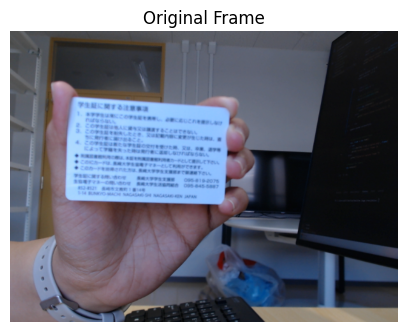

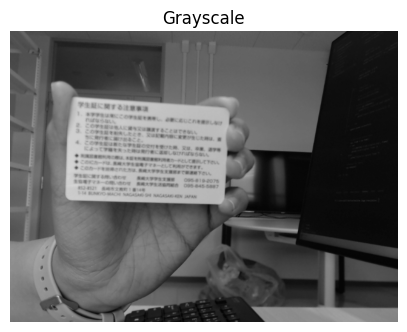

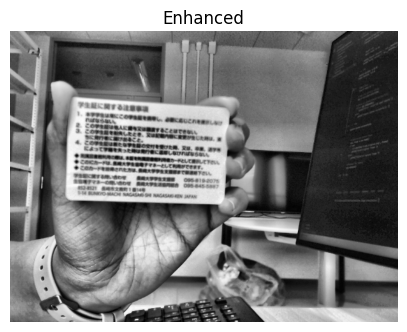

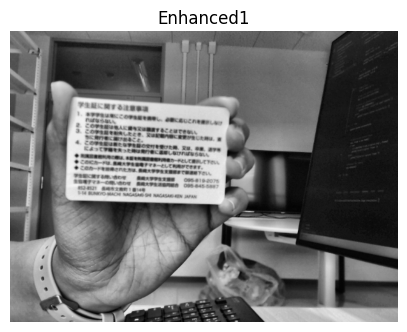

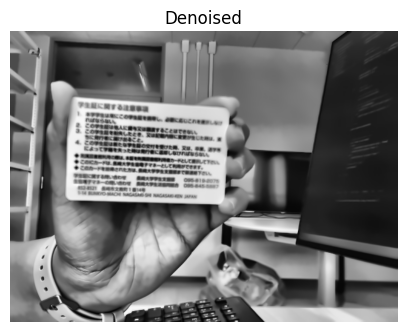

In [48]:
from matplotlib import pyplot as plt

def show_img(img_path, title=""):
    img = cv2.imread(img_path)        
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(5, 5))
    plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

show_img("frame_original.png", "Original Frame")
show_img("frame_gray.png", "Grayscale")
show_img("frame_enhanced.png", "Enhanced")
show_img("frame_enhanced1.png", "Enhanced1")
show_img("frame_denoised.png", "Denoised")